<a href="https://colab.research.google.com/github/vdadithya2002/3-2-Sem/blob/Object_detection/RCNN_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Implementing the RCNN on the Image using the pre-trained R-CNN model


Load the `img.jfif` image using an appropriate library for image processing.


In [1]:
from PIL import Image

# Load the image
try:
    image = Image.open('img.jfif')
    print("Image loaded successfully.")
    print(f"Image format: {image.format}")
    print(f"Image size: {image.size}")
    print(f"Image mode: {image.mode}")
except FileNotFoundError:
    print("Error: img.jfif not found. Please ensure the image file is in the correct directory.")
except Exception as e:
    print(f"An error occurred while loading the image: {e}")

Image loaded successfully.
Image format: JPEG
Image size: (275, 183)
Image mode: RGB


## Load Pre-trained R-CNN Model

### Subtask:
Load a pre-trained R-CNN (Region-based Convolutional Neural Network) model, including its architecture and weights, for object detection. This step will also handle loading necessary class labels.


In [2]:
pip install torchvision

In [3]:
import torchvision

# Load a pre-trained Faster R-CNN model with a ResNet-50-FPN backbone
model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=True)

# Set the model to evaluation mode
model.eval()

# Define COCO dataset class labels
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A',
    'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

print("Pre-trained Faster R-CNN model loaded and set to evaluation mode.")
print(f"Number of COCO classes defined: {len(COCO_CLASSES)}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 131MB/s]


Pre-trained Faster R-CNN model loaded and set to evaluation mode.
Number of COCO classes defined: 91


**Reasoning**:
Now that the image is loaded and the model is ready, the next step is to prepare the image for input to the pre-trained R-CNN model. This involves converting the PIL Image object into a PyTorch tensor and applying the necessary transformations (like normalization) that the model expects.



In [4]:
import torchvision.transforms as T

# Define the transformation pipeline
transform = T.Compose([
    T.ToTensor(),
])

# Apply the transformation to the loaded image
input_tensor = transform(image)

# Add a batch dimension (model expects a batch of images)
input_batch = input_tensor.unsqueeze(0)

print("Image transformed to tensor and ready for model input.")
print(f"Input tensor shape: {input_batch.shape}")

Image transformed to tensor and ready for model input.
Input tensor shape: torch.Size([1, 3, 183, 275])


In [5]:
import torch

# Perform inference
with torch.no_grad():
    predictions = model(input_batch)

print("Object detection inference completed.")
print(f"Number of detected objects in the first image: {len(predictions[0]['labels'])}")
# print(predictions)


Object detection inference completed.
Number of detected objects in the first image: 3


In [6]:
detection_threshold = 0.8 # Define a confidence threshold

# Get the first image's predictions (assuming batch size of 1)
output = predictions[0]

# Filter predictions based on confidence threshold
boxes = output['boxes'][output['scores'] > detection_threshold]
labels = output['labels'][output['scores'] > detection_threshold]
scores = output['scores'][output['scores'] > detection_threshold]

# Map numerical labels to COCO class names
detected_class_names = [COCO_CLASSES[label] for label in labels]

print(f"Filtered detections (confidence > {detection_threshold}):")
print(f"  Number of detected objects: {len(boxes)}")
for i in range(len(boxes)):
    print(f"  - Object: {detected_class_names[i]}, Score: {scores[i]:.2f}, Box: {boxes[i].tolist()}")


Filtered detections (confidence > 0.8):
  Number of detected objects: 2
  - Object: person, Score: 1.00, Box: [56.85041046142578, 53.72053527832031, 140.52821350097656, 137.3175048828125]
  - Object: backpack, Score: 0.98, Box: [87.17878723144531, 62.93136215209961, 111.40034484863281, 101.90983581542969]


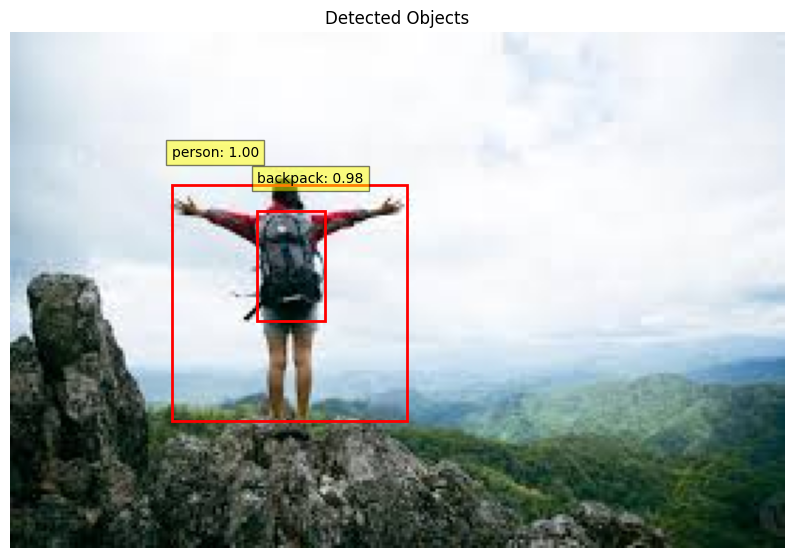

Visualized detected objects with bounding boxes, labels, and scores.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Convert the PIL image to a format suitable for plotting with matplotlib
# Ensure the image is in RGB format if it was not already (PIL handles this well for 'RGB' mode)
image_np = image # Original PIL image

# Create figure and axes
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(image_np)

# Iterate over the filtered detections and draw bounding boxes
for i in range(len(boxes)):
    box = boxes[i].tolist()
    label = detected_class_names[i]
    score = scores[i].item()

    # Extract coordinates
    xmin, ymin, xmax, ymax = box

    # Create a Rectangle patch
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='r', facecolor='none')

    # Add the patch to the Axes
    ax.add_patch(rect)

    # Add label and score text
    ax.text(xmin, ymin - 10, f'{label}: {score:.2f}',
            bbox=dict(facecolor='yellow', alpha=0.5), fontsize=10, color='black')

ax.axis('off') # Hide axes ticks and labels
plt.title('Detected Objects')
plt.show()

print("Visualized detected objects with bounding boxes, labels, and scores.")

In [8]:
print("\n--- Object Detection Summary ---")
if len(detected_class_names) == 0:
    print("No objects detected with confidence > 0.8.")
else:
    print(f"Detected {len(detected_class_names)} object(s):")
    for i, class_name in enumerate(detected_class_names):
        score_val = scores[i].item()
        box_coords = boxes[i].tolist()
        print(f"  - {class_name} (Confidence: {score_val:.2f}) at Bounding Box: [{box_coords[0]:.2f}, {box_coords[1]:.2f}, {box_coords[2]:.2f}, {box_coords[3]:.2f}]")

print("Object detection summary completed.")


--- Object Detection Summary ---
Detected 2 object(s):
  - person (Confidence: 1.00) at Bounding Box: [56.85, 53.72, 140.53, 137.32]
  - backpack (Confidence: 0.98) at Bounding Box: [87.18, 62.93, 111.40, 101.91]
Object detection summary completed.
